<a href="https://colab.research.google.com/github/Reshsajee/my-project-resh/blob/main/Copy_of_vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch torchvision timm matplotlib scikit-learn

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import timm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import os

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import pandas as pd

images_dir = "/content/drive/MyDrive/2mush/mh-dataset/images"
labels_dir = "/content/drive/MyDrive/2mush/mh-dataset/labels"

# Prepare lists
image_files = []
labels = []

# Loop through all text files in labels folder
for txt_file in os.listdir(labels_dir):
    if txt_file.endswith(".txt"):
        label_path = os.path.join(labels_dir, txt_file)
        with open(label_path, "r") as f:
            label = f.read().strip()  # Read label and remove whitespace

        # Derive image filename from text file name
        image_name = txt_file.replace(".txt", ".jpg")  # adjust if images are png

        # Append to lists
        image_files.append(image_name)
        labels.append(label)

# Create DataFrame
df = pd.DataFrame({"image": image_files, "label": labels})
print(df.head())

                     image                                              label
0  IMG_20220722_122600.jpg              0 0.533279 0.558622 0.241883 0.523088
1  IMG_20220722_122356.jpg  0 0.368101 0.325938 0.033279 0.097403\n0 0.384...
2  IMG_20220722_122133.jpg              0 0.528409 0.502435 0.615260 0.995130
3  IMG_20220722_121921.jpg              0 0.620942 0.523449 0.178571 0.510462
4  IMG_20220722_122525.jpg              0 0.505276 0.468434 0.158279 0.295815


In [6]:
import os
import pandas as pd

images_dir = "/content/drive/MyDrive/2mush/mh-dataset/images"
labels_dir = "/content/drive/MyDrive/2mush/mh-dataset/labels"

# Map numeric code to stage name
stage_map = {0: "pinhead", 1: "growing", 2: "mature"}

image_files = []
labels = []

for txt_file in os.listdir(labels_dir):
    if txt_file.endswith(".txt"):
        txt_path = os.path.join(labels_dir, txt_file)
        with open(txt_path, "r") as f:
            line = f.readline().strip()          # Read first line
            first_part = line.split()[0]         # Take first element
            # Extract numeric part if it starts with "Stage"
            if first_part.startswith("Stage"):
                code = int(first_part.replace("Stage", ""))
            else:
                code = int(float(first_part))    # Handle regular numbers like 0,1,2

            label = stage_map[code]              # Map to stage name

        # Get corresponding image filename
        image_name = txt_file.replace(".txt", ".jpg")  # change to .png if needed

        image_files.append(image_name)
        labels.append(label)

# Create DataFrame
df = pd.DataFrame({"image": image_files, "label": labels})
print(df.head())

# Optional: save CSV
df.to_csv("/content/drive/MyDrive/2mush/mh-dataset/labels_combined.csv", index=False)

                     image    label
0  IMG_20220722_122600.jpg  pinhead
1  IMG_20220722_122356.jpg  pinhead
2  IMG_20220722_122133.jpg  pinhead
3  IMG_20220722_121921.jpg  pinhead
4  IMG_20220722_122525.jpg  pinhead


In [8]:
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import os

class MushroomDataset(Dataset):
    def __init__(self, images_dir, labels_file, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        self.df = pd.read_csv(labels_file)
        self.classes = sorted(self.df['label'].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image']
        label_name = self.df.iloc[idx]['label']
        label = self.class_to_idx[label_name]

        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [12]:
labels_file = "/content/drive/MyDrive/2mush/mh-dataset/labels_combined.csv"

dataset = MushroomDataset(images_dir, labels_file, transform=transform)

In [13]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),                 # Resize images to 224x224
    transforms.ToTensor(),                         # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Normalize like ImageNet
                         std=[0.229, 0.224, 0.225])
])

In [14]:
from torch.utils.data import Dataset
from PIL import Image
import os
import pandas as pd

class MushroomDataset(Dataset):
    def __init__(self, images_dir, labels_file, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        self.df = pd.read_csv(labels_file)
        self.classes = sorted(self.df['label'].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image']
        label_name = self.df.iloc[idx]['label']
        label = self.class_to_idx[label_name]

        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
import os
import pandas as pd

images_dir = "/content/drive/MyDrive/2mush/mh-dataset/images"
labels_file = "/content/drive/MyDrive/2mush/mh-dataset/labels_combined.csv"

# Load CSV
df = pd.read_csv(labels_file)

# Get list of actual images in the folder
existing_images = set(os.listdir(images_dir))

# Keep only rows where the image exists
df = df[df['image'].isin(existing_images)]

# Save cleaned CSV
df.to_csv(labels_file, index=False)

print(f"CSV cleaned. Total valid images: {len(df)}")

CSV cleaned. Total valid images: 1127


In [16]:
import torch
import torch.nn as nn
import timm  # PyTorch Image Models

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pretrained ViT (e.g., ViT-Base)
model = timm.create_model('vit_base_patch16_224', pretrained=True)

# Change the classifier head to match 3 classes (pinhead, growing, mature)
model.head = nn.Linear(model.head.in_features, 3)

# Move model to GPU
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(model)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [17]:
import os
import pandas as pd

images_dir = "/content/drive/MyDrive/2mush/mh-dataset/images"
labels_file = "/content/drive/MyDrive/2mush/mh-dataset/labels_combined.csv"

# Load CSV
df = pd.read_csv(labels_file)

# Get list of actual images in the folder
existing_images = set(os.listdir(images_dir))

# Keep only rows where the image exists
df = df[df['image'].isin(existing_images)]

# Save cleaned CSV
df.to_csv(labels_file, index=False)

print(f"CSV cleaned. Total valid images: {len(df)}")

CSV cleaned. Total valid images: 1127


In [18]:
dataset = MushroomDataset(images_dir, labels_file, transform=transform)

In [19]:
from torch.utils.data import DataLoader, random_split

# Recreate dataset with transforms
dataset = MushroomDataset(images_dir, labels_file, transform=transform)

# Split into train/test (80/20)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

print("Classes:", dataset.classes)
print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Classes: ['growing', 'mature', 'pinhead']
Train samples: 901, Test samples: 226


In [20]:
import torch
from tqdm import tqdm

num_epochs = 10  # adjust as needed

# Make sure your model is already on GPU
model.train()

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track training stats
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total * 100
    print(f"Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_acc:.2f}%")

    # Evaluate on test set
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    test_acc = test_correct / test_total * 100
    print(f"Test Accuracy: {test_acc:.2f}%\n")

    model.train()  # set back to training mode

Epoch 1/10: 100%|██████████| 57/57 [02:02<00:00,  2.16s/it]

Train Loss: 0.5311, Train Accuracy: 75.36%


Test Accuracy: 80.97%



Epoch 2/10: 100%|██████████| 57/57 [01:39<00:00,  1.75s/it]

Train Loss: 0.3481, Train Accuracy: 85.02%


...

Train Loss: 0.0194, Train Accuracy: 99.00%


Test Accuracy: 82.30%



Epoch 10/10: 100%|██████████| 57/57 [01:40<00:00,  1.77s/it]

Train Loss: 0.0869, Train Accuracy: 96.67%


Test Accuracy: 85.40%



In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import torch
import numpy as np

model.eval()  # set to evaluation mode

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=dataset.classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

Classification Report:
              precision    recall  f1-score   support

     growing       0.66      0.77      0.71        53
      mature       0.87      0.73      0.80        56
     pinhead       0.95      0.95      0.95       117

    accuracy                           0.85       226
   macro avg       0.83      0.82      0.82       226
weighted avg       0.86      0.85      0.86       226

Confusion Matrix:
[[ 41   6   6]
 [ 15  41   0]
 [  6   0 111]]


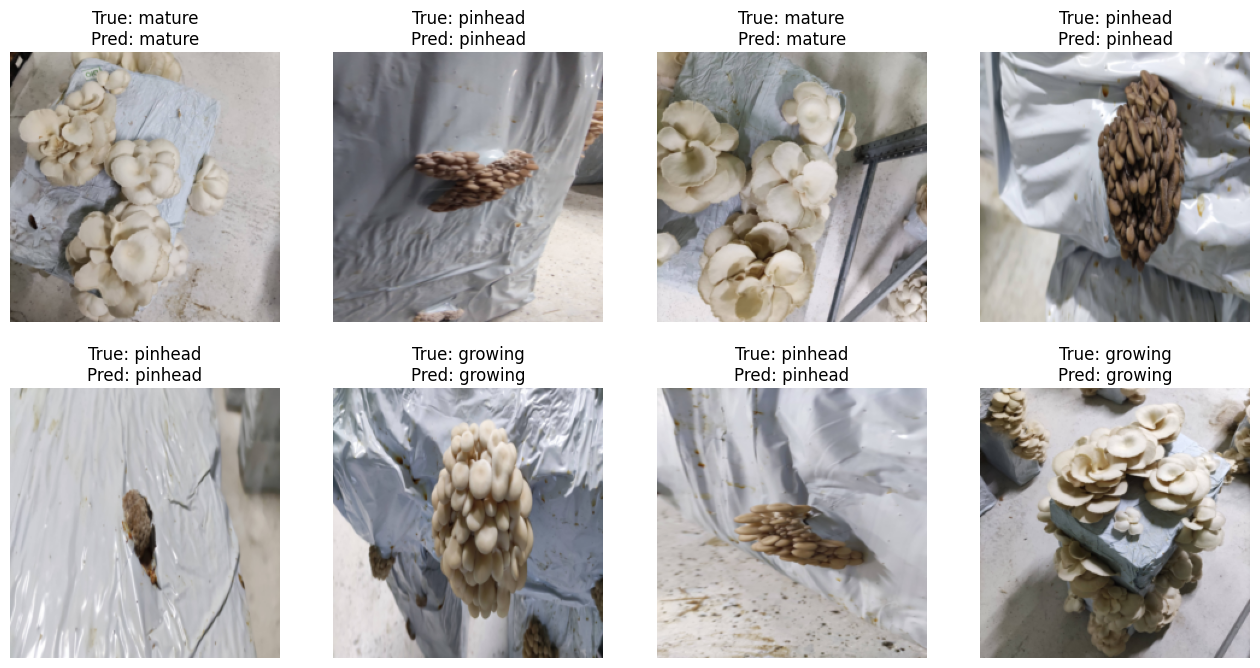

In [22]:
import matplotlib.pyplot as plt
import torch

# Get a batch of test images
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

# Move images and labels to CPU for plotting
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

# Plot first 8 images with predicted and true labels
plt.figure(figsize=(16, 8))
for i in range(8):
    plt.subplot(2, 4, i+1)
    img = images[i].permute(1, 2, 0)  # CHW -> HWC
    img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])  # unnormalize
    img = torch.clamp(img, 0, 1)
    plt.imshow(img)
    plt.title(f"True: {dataset.classes[labels[i]]}\nPred: {dataset.classes[preds[i]]}")
    plt.axis('off')
plt.show()

Predicted Stage: pinhead


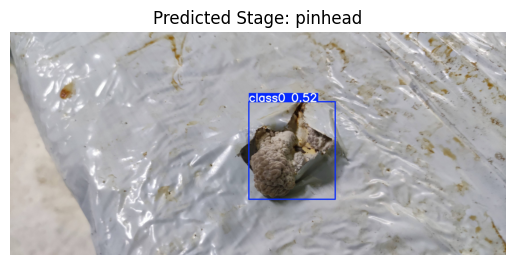

In [24]:
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

# Path to your custom image
custom_image_path = "/content/drive/MyDrive/2mush/initial.jpg"

# Define the same transforms as training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load and preprocess the image
image = Image.open(custom_image_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0)  # add batch dimension
input_tensor = input_tensor.to(device)

# Set model to eval mode
model.eval()
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)

# Get class name
predicted_class = dataset.classes[predicted.item()]
print(f"Predicted Stage: {predicted_class}")

# Optional: display the image
plt.imshow(image)
plt.title(f"Predicted Stage: {predicted_class}")
plt.axis('off')
plt.show()